In [1]:
import os
import json

import numpy as np
import matplotlib.pyplot as plt

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

from build_finesat_dataset import build_finesat_dataset

In [2]:
DATASET_DIR = os.path.join('..', 'geometry-consistent-data')
FILENAME = "gc_c3.2_data1.json"
RTCM_PATH = os.path.join(os.getcwd(), "..", "..", "gnss-data-collection",
                         "window-experiment", "data", "samples")

with open(os.path.join(DATASET_DIR, FILENAME), 'r') as f:
    data = json.load(f)

In [3]:
window0_data_paths = []
window0 = data[0]
for i in range(0, len(window0)):
    window0_data_paths.append(os.path.join(RTCM_PATH, window0[i][0]))

window1_data_paths = []
window1 = data[1]
for i in range(0, len(window1)):
    window1_data_paths.append(os.path.join(RTCM_PATH, window1[i][0]))

window2_data_paths = []
window2 = data[2]
for i in range(0, len(window2)):
    window2_data_paths.append(os.path.join(RTCM_PATH, window2[i][0]))

window3_data_paths = []
window3 = data[3]
for i in range(0, len(window3)):
    window3_data_paths.append(os.path.join(RTCM_PATH, window3[i][0]))

In [27]:
X0_fs, Y0_fs = build_finesat_dataset(window0_data_paths)
X1_fs, Y1_fs = build_finesat_dataset(window1_data_paths)
X2_fs, Y2_fs = build_finesat_dataset(window2_data_paths)
X3_fs, Y3_fs = build_finesat_dataset(window3_data_paths)

X01_fs = np.concatenate((X0_fs, X1_fs))
X02_fs = np.concatenate((X0_fs, X2_fs))
X03_fs = np.concatenate((X0_fs, X3_fs))
X12_fs = np.concatenate((X1_fs, X2_fs))
X13_fs = np.concatenate((X1_fs, X3_fs))
X23_fs = np.concatenate((X2_fs, X3_fs))

def trim_window(arr):
    new_arr = []

    for label in arr:
        underscore_index = label.find('_')
        new_arr.append(label[:underscore_index])

    return new_arr

Y01_fs = np.concatenate((Y0_fs, Y1_fs))
Y01_fs = np.array(trim_window(Y01_fs))

Y02_fs = np.concatenate((Y0_fs, Y2_fs))
Y02_fs = np.array(trim_window(Y02_fs))

Y03_fs = np.concatenate((Y0_fs, Y3_fs))
Y03_fs = np.array(trim_window(Y03_fs))

Y12_fs = np.concatenate((Y1_fs, Y2_fs))
Y12_fs = np.array(trim_window(Y12_fs))

Y13_fs = np.concatenate((Y1_fs, Y3_fs))
Y13_fs = np.array(trim_window(Y13_fs))

Y23_fs = np.concatenate((Y2_fs, Y3_fs))
Y23_fs = np.array(trim_window(Y23_fs))

Processing 46 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (46, 78)  -> (46 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (46,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 60 files for FINESAT Pipeline...

FineSat Dataset Built!
Feature Matrix (X) Shape: (60, 78)  -> (60 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (60,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 90 files for FINESAT Pipeline...


Unknown protocol header b'\xd3m'.
Unknown protocol header b'$\x04'.
Unknown protocol header b'\xd3\x80'.
Unknown protocol header b'$x'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'\xd3D'.
Unknown protocol header b'\xd3w'.
Unknown protocol header b'$\x06'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\xfa'.
Unknown protocol header b'$\xe2'.
Unknown protocol header b'$;'.
Unknown protocol header b'$\t'.
Unknown protocol header b'\xb5 '.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xd7'.
Unknown protocol header b'\xb5\x9f'.
Unknown protocol header b'\xd3Z'.
Unknown protocol header b'\xd3\xde'.
Unknown protocol header b'\xb5\x9b'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5^'.
Unknown protocol header b'\xd3\x9d'.
Serial stream terminated unexpectedly. 1874 bytes requested, 955 bytes returned.
Unknown protocol header b'$K'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x95'.
Unknown protocol heade


FineSat Dataset Built!
Feature Matrix (X) Shape: (90, 78)  -> (90 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (90,)
Saved as ./X_finesat.npy and ./Y_finesat.npy
Processing 78 files for FINESAT Pipeline...


Unknown protocol header b'\xb5\x8b'.
Serial stream terminated unexpectedly. 170 bytes requested, 126 bytes returned.
Unknown protocol header b'$g'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xb5\x8a'.
Unknown protocol header b'\xb5\x97'.
Unknown protocol header b'\xd3\xed'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'\xd3\xf7'.
Unknown protocol header b'$0'.
Unknown protocol header b'$\x05'.
Unknown protocol header b'$\x05'.



FineSat Dataset Built!
Feature Matrix (X) Shape: (78, 78)  -> (78 samples, 6 sats * 13 features)
Labels Array (Y) Shape:   (78,)
Saved as ./X_finesat.npy and ./Y_finesat.npy


Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.50
Fold 2: Accuracy = 0.44
Fold 3: Accuracy = 0.67
Fold 4: Accuracy = 0.56
Fold 5: Accuracy = 0.33

Average Accuracy: 0.50 ± 0.11


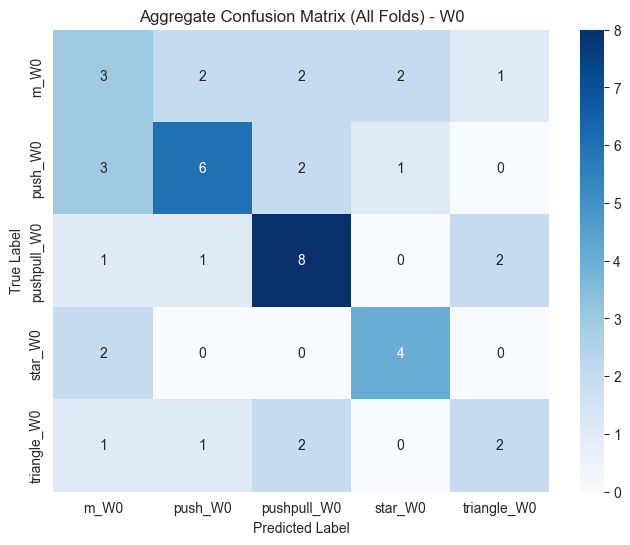

In [57]:
le = LabelEncoder()
Y0_encoded = le.fit_transform(Y0_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies0 = []
# To aggregate confusion matrix over all folds
cm_total0 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X0_fs, Y0_encoded)):
    X0_train, X0_test = X0_fs[train_idx], X0_fs[test_idx]
    y0_train, y0_test = Y0_encoded[train_idx], Y0_encoded[test_idx]

    # Simple default XGBoost model
    model0 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model0.fit(X0_train, y0_train)

    preds0 = model0.predict(X0_test)
    acc0 = accuracy_score(y0_test, preds0)
    accuracies0.append(acc0)

    cm0 = confusion_matrix(y0_test, preds0, labels=range(len(le.classes_)))
    cm_total0 += cm0

    print(f"Fold {fold+1}: Accuracy = {acc0:.2f}")

print(f"\nAverage Accuracy: {np.mean(accuracies0):.2f} ± {np.std(accuracies0):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total0, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W0")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.42
Fold 2: Accuracy = 0.58
Fold 3: Accuracy = 0.50
Fold 4: Accuracy = 0.17
Fold 5: Accuracy = 0.50

Average Accuracy: 0.43 ± 0.14


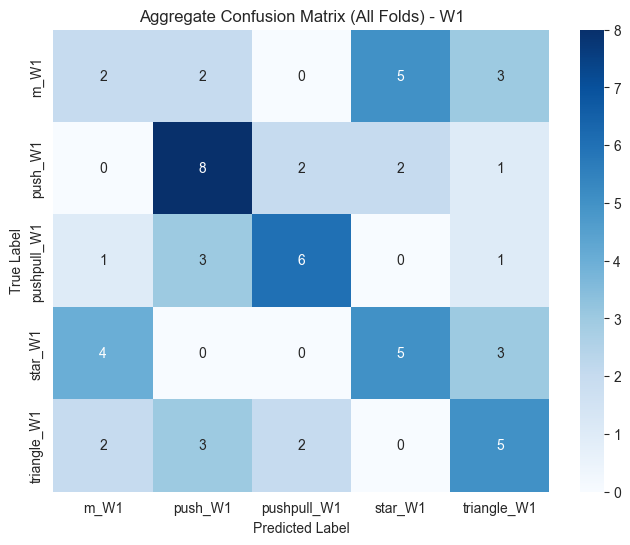

In [43]:
le = LabelEncoder()
Y1_encoded = le.fit_transform(Y1_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies1 = []
# To aggregate confusion matrix over all folds
cm_total1 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X1_fs, Y1_encoded)):
    X1_train, X1_test = X1_fs[train_idx], X1_fs[test_idx]
    y1_train, y1_test = Y1_encoded[train_idx], Y1_encoded[test_idx]

    # Simple default XGBoost model
    model1 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model1.fit(X1_train, y1_train)

    preds1 = model1.predict(X1_test)
    acc1 = accuracy_score(y1_test, preds1)
    accuracies1.append(acc1)

    cm1 = confusion_matrix(y1_test, preds1, labels=range(len(le.classes_)))
    cm_total1 += cm1

    print(f"Fold {fold+1}: Accuracy = {acc1:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies1):.2f} ± {np.std(accuracies1):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total1, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.50
Fold 2: Accuracy = 0.61
Fold 3: Accuracy = 0.39
Fold 4: Accuracy = 0.39
Fold 5: Accuracy = 0.33

Average Accuracy: 0.44 ± 0.10


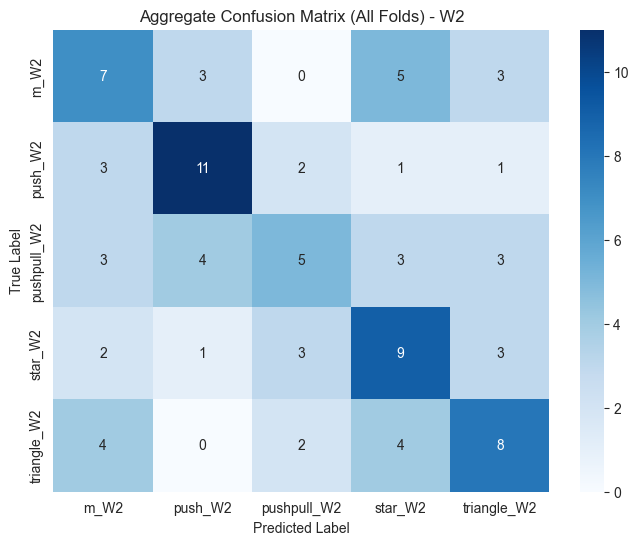

In [44]:
le = LabelEncoder()
Y2_encoded = le.fit_transform(Y2_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies2 = []
# To aggregate confusion matrix over all folds
cm_total2 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X2_fs, Y2_encoded)):
    X2_train, X2_test = X2_fs[train_idx], X2_fs[test_idx]
    y2_train, y2_test = Y2_encoded[train_idx], Y2_encoded[test_idx]

    # Simple default XGBoost model
    model2 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model2.fit(X2_train, y2_train)

    preds2 = model2.predict(X2_test)
    acc2 = accuracy_score(y2_test, preds2)
    accuracies2.append(acc2)

    cm2 = confusion_matrix(y2_test, preds2, labels=range(len(le.classes_)))
    cm_total2 += cm2

    print(f"Fold {fold+1}: Accuracy = {acc2:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies2):.2f} ± {np.std(accuracies2):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total2, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.44
Fold 2: Accuracy = 0.62
Fold 3: Accuracy = 0.56
Fold 4: Accuracy = 0.53
Fold 5: Accuracy = 0.47

Average Accuracy: 0.53 ± 0.07


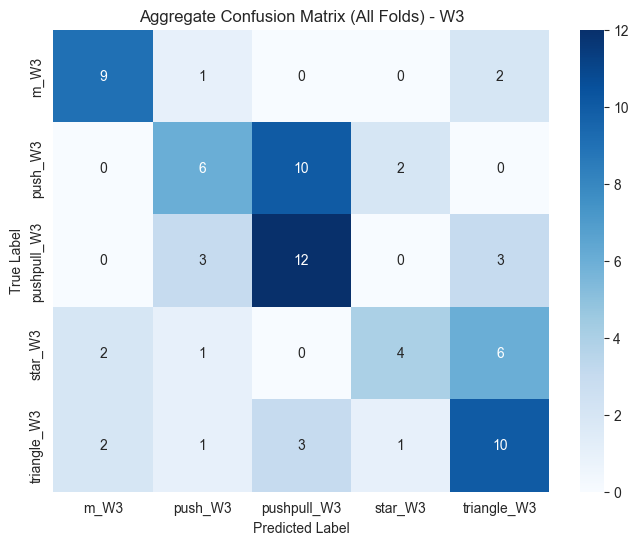

In [45]:
le = LabelEncoder()
Y3_encoded = le.fit_transform(Y3_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies3 = []
# To aggregate confusion matrix over all folds
cm_total3 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X3_fs, Y3_encoded)):
    X3_train, X3_test = X3_fs[train_idx], X3_fs[test_idx]
    y3_train, y3_test = Y3_encoded[train_idx], Y3_encoded[test_idx]

    # Simple default XGBoost model
    model3 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model3.fit(X3_train, y3_train)

    preds3 = model3.predict(X3_test)
    acc3 = accuracy_score(y3_test, preds3)
    accuracies3.append(acc3)

    cm3 = confusion_matrix(y3_test, preds3, labels=range(len(le.classes_)))
    cm_total3 += cm3

    print(f"Fold {fold+1}: Accuracy = {acc3:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies3):.2f} ± {np.std(accuracies3):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total3, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Classifier trained across windows

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.36
Fold 2: Accuracy = 0.43
Fold 3: Accuracy = 0.57
Fold 4: Accuracy = 0.24
Fold 5: Accuracy = 0.33

Average Accuracy: 0.39 ± 0.11


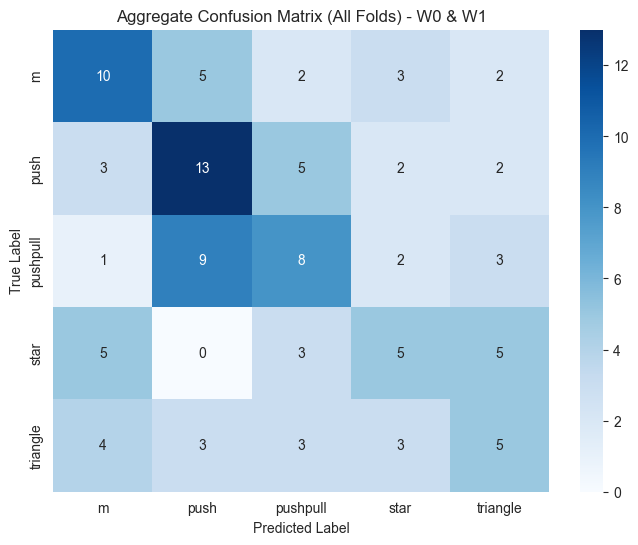

In [32]:
le = LabelEncoder()
Y01_encoded = le.fit_transform(Y01_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies01 = []
# To aggregate confusion matrix over all folds
cm_total01 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X01_fs, Y01_encoded)):
    X01_train, X01_test = X01_fs[train_idx], X01_fs[test_idx]
    y01_train, y01_test = Y01_encoded[train_idx], Y01_encoded[test_idx]

    # Simple default XGBoost model
    model01 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model01.fit(X01_train, y01_train)

    preds01 = model01.predict(X01_test)
    acc01 = accuracy_score(y01_test, preds01)
    accuracies01.append(acc01)

    cm01 = confusion_matrix(y01_test, preds01, labels=range(len(le.classes_)))
    cm_total01 += cm01

    print(f"Fold {fold+1}: Accuracy = {acc01:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies01):.2f} ± {np.std(accuracies01):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total01, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W0 & W1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.25
Fold 2: Accuracy = 0.52
Fold 3: Accuracy = 0.37
Fold 4: Accuracy = 0.33
Fold 5: Accuracy = 0.44

Average Accuracy: 0.38 ± 0.09


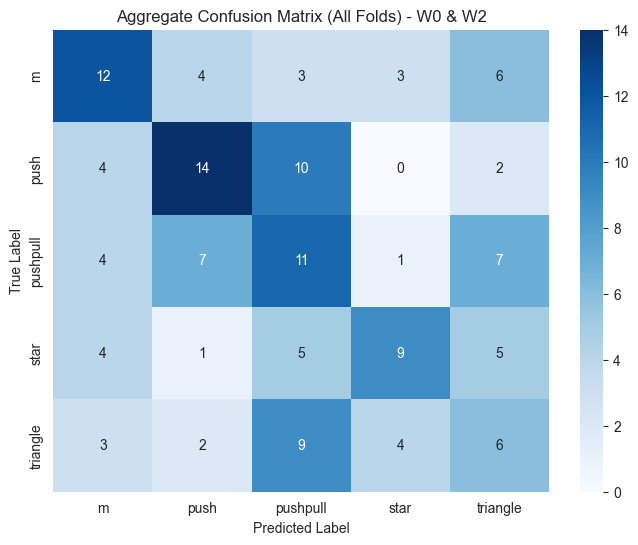

In [38]:
le = LabelEncoder()
Y02_encoded = le.fit_transform(Y02_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies02 = []
# To aggregate confusion matrix over all folds
cm_total02 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X02_fs, Y02_encoded)):
    X02_train, X02_test = X02_fs[train_idx], X02_fs[test_idx]
    y02_train, y02_test = Y02_encoded[train_idx], Y02_encoded[test_idx]

    # Simple default XGBoost model
    model02 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model02.fit(X02_train, y02_train)

    preds02 = model02.predict(X02_test)
    acc02 = accuracy_score(y02_test, preds02)
    accuracies02.append(acc02)

    cm02 = confusion_matrix(y02_test, preds02, labels=range(len(le.classes_)))
    cm_total02 += cm02

    print(f"Fold {fold+1}: Accuracy = {acc02:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies02):.2f} ± {np.std(accuracies02):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total02, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W0 & W2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.44
Fold 2: Accuracy = 0.28
Fold 3: Accuracy = 0.52
Fold 4: Accuracy = 0.36
Fold 5: Accuracy = 0.42

Average Accuracy: 0.40 ± 0.08


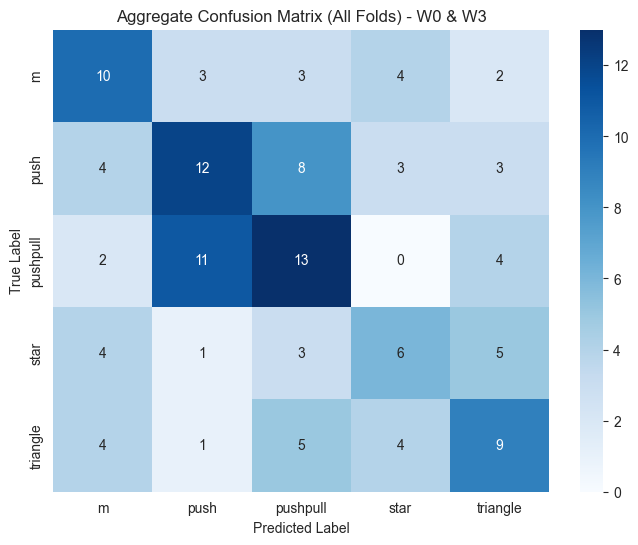

In [34]:
le = LabelEncoder()
Y03_encoded = le.fit_transform(Y03_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies03 = []
# To aggregate confusion matrix over all folds
cm_total03 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X03_fs, Y03_encoded)):
    X03_train, X03_test = X03_fs[train_idx], X03_fs[test_idx]
    y03_train, y03_test = Y03_encoded[train_idx], Y03_encoded[test_idx]

    # Simple default XGBoost model
    model03 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model03.fit(X03_train, y03_train)

    preds03 = model03.predict(X03_test)
    acc03 = accuracy_score(y03_test, preds03)
    accuracies03.append(acc03)

    cm03 = confusion_matrix(y03_test, preds03, labels=range(len(le.classes_)))
    cm_total03 += cm03

    print(f"Fold {fold+1}: Accuracy = {acc03:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies03):.2f} ± {np.std(accuracies03):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total03, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W0 & W3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.23
Fold 2: Accuracy = 0.53
Fold 3: Accuracy = 0.50
Fold 4: Accuracy = 0.47
Fold 5: Accuracy = 0.27

Average Accuracy: 0.40 ± 0.12


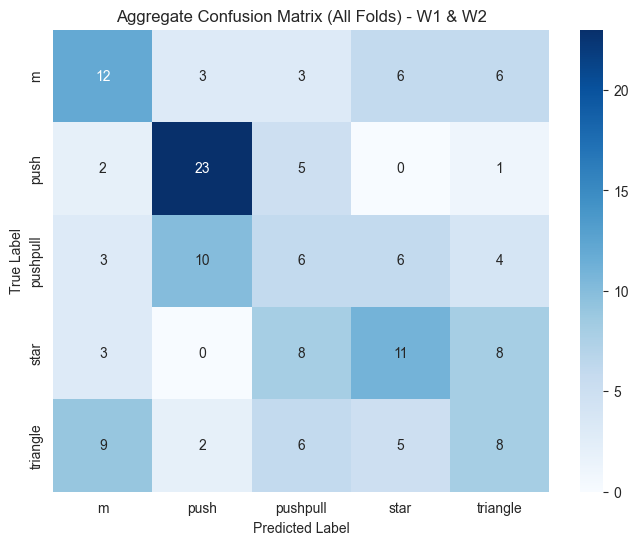

In [35]:
le = LabelEncoder()
Y12_encoded = le.fit_transform(Y12_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies12 = []
# To aggregate confusion matrix over all folds
cm_total12 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X12_fs, Y12_encoded)):
    X12_train, X12_test = X12_fs[train_idx], X12_fs[test_idx]
    y12_train, y12_test = Y12_encoded[train_idx], Y12_encoded[test_idx]

    # Simple default XGBoost model
    model12 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model12.fit(X12_train, y12_train)

    preds12 = model12.predict(X12_test)
    acc12 = accuracy_score(y12_test, preds12)
    accuracies12.append(acc12)

    cm12 = confusion_matrix(y12_test, preds12, labels=range(len(le.classes_)))
    cm_total12 += cm12

    print(f"Fold {fold+1}: Accuracy = {acc12:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies12):.2f} ± {np.std(accuracies12):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total12, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W1 & W2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.36
Fold 2: Accuracy = 0.29
Fold 3: Accuracy = 0.46
Fold 4: Accuracy = 0.52
Fold 5: Accuracy = 0.48

Average Accuracy: 0.42 ± 0.09


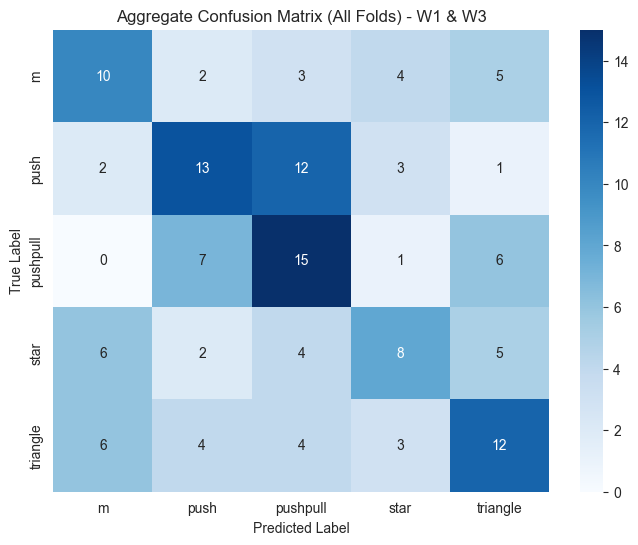

In [36]:
le = LabelEncoder()
Y13_encoded = le.fit_transform(Y13_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies13 = []
# To aggregate confusion matrix over all folds
cm_total13 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X13_fs, Y13_encoded)):
    X13_train, X13_test = X13_fs[train_idx], X13_fs[test_idx]
    y13_train, y13_test = Y13_encoded[train_idx], Y13_encoded[test_idx]

    # Simple default XGBoost model
    model13 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model13.fit(X13_train, y13_train)

    preds13 = model13.predict(X13_test)
    acc13 = accuracy_score(y13_test, preds13)
    accuracies13.append(acc13)

    cm13 = confusion_matrix(y13_test, preds13, labels=range(len(le.classes_)))
    cm_total13 += cm13

    print(f"Fold {fold+1}: Accuracy = {acc13:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies13):.2f} ± {np.std(accuracies13):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total13, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W1 & W3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Starting XGBoost 5-Fold CV...
Fold 1: Accuracy = 0.29
Fold 2: Accuracy = 0.41
Fold 3: Accuracy = 0.29
Fold 4: Accuracy = 0.39
Fold 5: Accuracy = 0.33

Average Accuracy: 0.35 ± 0.05


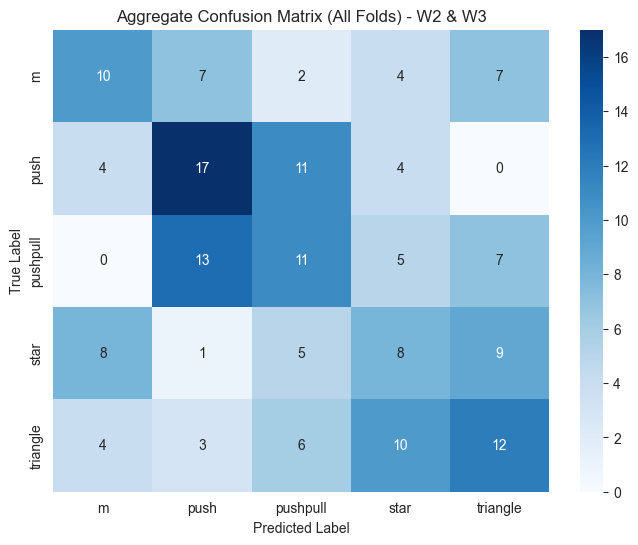

In [37]:
le = LabelEncoder()
Y23_encoded = le.fit_transform(Y23_fs)
# Setup K-Fold (using 5 splits)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies23 = []
# To aggregate confusion matrix over all folds
cm_total23 = np.zeros((len(le.classes_), len(le.classes_)))
print("Starting XGBoost 5-Fold CV...")
for fold, (train_idx, test_idx) in enumerate(kf.split(X23_fs, Y23_encoded)):
    X23_train, X23_test = X23_fs[train_idx], X23_fs[test_idx]
    y23_train, y23_test = Y23_encoded[train_idx], Y23_encoded[test_idx]

    # Simple default XGBoost model
    model23 = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
    model23.fit(X23_train, y23_train)

    preds23 = model23.predict(X23_test)
    acc23 = accuracy_score(y23_test, preds23)
    accuracies23.append(acc23)

    cm23 = confusion_matrix(y23_test, preds23, labels=range(len(le.classes_)))
    cm_total23 += cm23

    print(f"Fold {fold+1}: Accuracy = {acc23:.2f}")
print(f"\nAverage Accuracy: {np.mean(accuracies23):.2f} ± {np.std(accuracies23):.2f}")
# Plot the total Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_total23, annot=True, fmt='g', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Aggregate Confusion Matrix (All Folds) - W2 & W3")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [62]:
accuracies_ww = accuracies0 + accuracies1 + accuracies2 + accuracies3
print(f"Avg accuracy within windows: {np.mean(accuracies_ww):.2f}")

Avg accuracy within windows: 0.48


In [64]:
accuracies_aw = accuracies01 + accuracies02 + accuracies03 + accuracies12 + accuracies13 + accuracies23
print(f"Avg accuracy across windows: {np.mean(accuracies_aw):.2f}")

Avg accuracy across windows: 0.39
